# Прогноз спроса BikeSouth: нелинейные модели

**Цель проекта:**
Разработать и оценить нелинейную модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов BikeSouth на основе погодных и календарных факторов, чтобы повысить точность прогноза по сравнению с базовой линейной моделью.

**Задачи проекта:**
1. Проанализировать исходные данные и baseline-модель заказчика: изучить структуру датасетов, проверить качество данных, провести EDA и оценить метрики готовой линейной регрессии.
2. Построить и оптимизировать нелинейные модели: подготовить данные, создать необходимые признаки, обучить kNN Regressor и Decision Tree Regressor, а также подобрать гиперпараметры с помощью Optuna по метрике RMSE.
3. Выбрать лучшую модель и оценить её качество: сравнить модели по RMSE, MAE и R², проверить финальную модель на тестовой выборке, интерпретировать важность признаков и сформулировать рекомендации для BikeSouth.

**Предоставленные данные:**
| Признак | Описание | Единица измерения / Значения |
|----------|----------|------------------------------|
| Temperature | Температура воздуха | °C |
| Humidity | Относительная влажность воздуха | % |
| Windspeed | Скорость ветра | м/с |
| Visibility | Видимость | 10 м |
| Dew Point Temperature | Температура точки росы | °C |
| Solar Radiation | Солнечная радиация | MJ/м² |
| Rainfall | Количество осадков | мм |
| Snowfall | Количество снега | см |
| Seasons | Время года | Winter, Spring, Summer, Autumn |
| Holiday | Выходной/праздничный день | Holiday / No Holiday |
| Functioning Day | Рабочий день проката велосипедов | Yes / No |
| Night | Ночной период (00:00–05:59) | True / False |
| Morning | Утренний период (06:00–09:59) | True / False |
| Evening | Вечерний период (16:00–19:59) | True / False |
| Late Evening | Поздний вечер (20:00–23:59) | True / False |
| Daytime | Дневной период (10:00–15:59) — базовое состояние, если все остальные временные признаки = False | Неявно |
| Rented Bike Count | **Целевая переменная** — количество арендованных велосипедов за час | шт. |

## 1. Подготовка среды и загрузка данных

Установим все необходимые зависимости и загрузим данные

In [1]:
# Установка зависимостей
!pip install -q \
  scikit-learn==1.6.1 \
  numpy \
  pandas \
  seaborn \
  phik \
  joblib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Импорт основных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import phik
import joblib

In [3]:
# Random state
RANDOM_STATE=1703

# Целевой признак
TARGET_COL = 'Rented Bike Count'

In [4]:
# Настройка параметров библиотек
mpl.rcParams['figure.constrained_layout.use'] = True

In [5]:
# Загрузка датасетов с кешированием на диске
data_files = {
    'train': 'ds_s14_train_data.csv',
    'test': 'ds_s14_test_data.csv',
}

dfs = {}

for file, file_path in data_files.items():
    try:
        dfs[file] = pd.read_csv(f'./{file}')
        print(f'Dataset {file} found locally.')
    except:
        print(f'Dataset {file} not found locally.')
        dfs[file] = pd.read_csv(f'https://code.s3.yandex.net/datasets/{file_path}')
        dfs[file].to_csv(f'./{file}', index=False)

Dataset train found locally.
Dataset test found locally.


In [6]:
# Проверка размеров загруженных данных
dfs['train'].shape, dfs['test'].shape

((7008, 17), (1752, 17))

In [7]:
# Для удобства работы с данными, переместим данные в отдельные переменные
df = dfs['train']
df_test = dfs['test']

In [8]:
# Просмотр первых 5 строк датасета
df.head(5)

,Unnamed: 0,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


In [9]:
# Просмотр первых 5 строк датасета с тестовыми данными
df_test.head(5)

,Unnamed: 0,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


In [10]:
# Скачивание базовой модели
import os
from urllib.request import urlretrieve

BASE_MODEL_PATH = "baseline_linear_regression_pipeline.joblib"

if os.path.isfile(BASE_MODEL_PATH):
    print("Файл уже существует")
else:
    print("Скачивание файла...")
    urlretrieve('https://code.s3.yandex.net/data-scientist/baseline_linear_regression_pipeline.joblib', BASE_MODEL_PATH)

Файл уже существует


In [11]:
# Загрузка базовой модели
model_base = joblib.load(BASE_MODEL_PATH)
model_base

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidity',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_temperature',
                                                   'solar_radiation_mjm2',
                                                   'rainfallmm',
                                                   'snowfall_cm']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['seasons', 'holiday',
                                                   'functioning_day']),
                                                 ('time', 'passthrough',
                                                  ['time_period_evening',
                                                   'time_period_late_evening',
                                                   'time_period_morning',
                                                   'time_period_night'])])),
                ('model', LinearRegression())])

**Промежуточный вывод**
Выполнены следующие действия для дальнейшей работы:
- Все необходимые зависимости установлены. Частоиспользуемые зависимости сразу импортированы
- Определена общая константа для единого random_state 
- Тренировочные и тестовые данные загружены
- Базовая модель загружена

Можно переходить к анализу базовой модели

## 2. Анализ baseline-модели BikeSouth

Замерим ключевые метрики на базовой модели с помощью кросс-валидации

Для начала посмотрим из чего состоит базовая модель и какие признаки требует для работы

In [12]:
# Структура базовой модели
model_base.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['temperature', 'humidity', 'wind_speed_ms',
                                   'visibility_10m', 'dew_point_temperature',
                                   'solar_radiation_mjm2', 'rainfallmm',
                                   'snowfall_cm']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehot',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False

In [13]:
# Получение списка признаков, которые требует ColumnTransformer из базовой модели
np.concatenate([
    x[2]
    for x
    in model_base.named_steps['preprocessor'].transformers
]).tolist()


['temperature',
 'humidity',
 'wind_speed_ms',
 'visibility_10m',
 'dew_point_temperature',
 'solar_radiation_mjm2',
 'rainfallmm',
 'snowfall_cm',
 'seasons',
 'holiday',
 'functioning_day',
 'time_period_evening',
 'time_period_late_evening',
 'time_period_morning',
 'time_period_night']

In [14]:
df.columns.tolist()

['Unnamed: 0',
 'Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Seasons',
 'Holiday',
 'Functioning Day',
 'Time_Period_Evening',
 'Time_Period_Late Evening',
 'Time_Period_Morning',
 'Time_Period_Night',
 'Rented Bike Count']

Имена признаков, которые требует базовая модель, и, которые переданы для нам для работы, отличаются. Поэтому напишем кастомный трансформер для преобразования имен и объединим его в один пайплайн с базовой моделью

In [15]:
# Кастомный трансформер для преобразования имен признаков
from sklearn.base import BaseEstimator, TransformerMixin

class RenameColumnsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.columns_mapping = {
            "Temperature": "temperature",
            "Humidity(%)": "humidity",
            "Wind speed (m/s)": "wind_speed_ms",
            "Visibility (10m)": "visibility_10m",
            "Dew point temperature": "dew_point_temperature",
            "Solar Radiation (MJ/m2)": "solar_radiation_mjm2",
            "Rainfall(mm)": "rainfallmm",
            "Snowfall (cm)": "snowfall_cm",
            "Seasons": "seasons",
            "Holiday": "holiday",
            "Functioning Day": "functioning_day",
            "Time_Period_Evening": "time_period_evening",
            "Time_Period_Late Evening": "time_period_late_evening",
            "Time_Period_Morning": "time_period_morning",
            "Time_Period_Night": "time_period_night",
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.rename(columns=self.columns_mapping)

In [16]:
# Добавление кастомного трансформера в пайплайн
from sklearn.pipeline import Pipeline

model_base = Pipeline([
    ('rename_columns', RenameColumnsTransformer()),
    ('default_model', model_base)
])

In [17]:
# Инициализация класса для разбиения данных на кросс-валидации
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [18]:
# Объект со списком метрик для оценки модели
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

In [19]:
# Общий объект для хранения метрик
cv_results = pd.DataFrame({
    'rmse': [],
    'mae': [],
    'r2': []
}, index=pd.Index([], name='model'))
cv_results

,rmse,mae,r2
model,,,


In [20]:
# Вспомогатлеьная функция для добавления метрик в общий объект
def add_metrics(model, cv_result):
    if (model in cv_results.index):
        raise ValueError(f"Model {model} already exists in cv_results")
        
    cv_results.loc[model] = [
        -cv_result['test_rmse'].mean(),
        -cv_result['test_mae'].mean(),
        cv_result['test_r2'].mean()
    ]

    cv_results.sort_values(
        by=['rmse', 'r2', 'mae'],
        ascending=[True, False, True],
        inplace=True
    )
    

In [21]:
# Замер метрик базовой модели на тренировочной выборке
from sklearn.model_selection import cross_validate

cv_result = cross_validate(
    model_base,
    df.drop(columns=TARGET_COL),
    df[TARGET_COL],
    cv=cv,
    scoring=scoring
)

add_metrics('model_base_train', cv_result)

In [22]:
# Замер метрик базовой модели на тестовой выборке
cv_result = cross_validate(
    model_base,
    df_test.drop(columns=TARGET_COL),
    df_test[TARGET_COL],
    cv=cv,
    scoring=scoring
)

add_metrics('model_base_test', cv_result)

In [23]:
# Вывод результатов
cv_results

,rmse,mae,r2
model,,,
model_base_test,412.558722,311.450990,0.582593
model_base_train,413.450713,309.970696,0.590566


По результатам оценки базовая модель демонстрирует сопоставимое качество на обучающей и тестовой выборках. Значение коэффициента детерминации R2 составляет 0.59 на обучении и 0.58 на тесте, то есть модель объясняет примерно 58–59% вариации целевой переменной. Средняя абсолютная ошибка (MAE) находится на уровне 310 велосипедов, а среднеквадратичная ошибка (RMSE) — около 413 велосипедов. Таким образом, в среднем прогноз модели отклоняется от фактического значения на 300–400 велосипедов, что указывает на умеренную точность и наличие значительной доли необъяснённой вариации в данных.

Полученный результат будет использоваться как базовый для сравнения с более сложными моделями. Линейная регрессия показывает приемлемое качество и позволяет выявить основные зависимости в данных. Далее будут рассмотрены модели KNN и дерева решений, чтобы оценить возможность повышения точности прогнозирования.

## 3. Исследовательский анализ данных (EDA)

Исследовательский анализ данных будет касаться только тренировочных данных. Тестовые данные будут применены только при конечной оценке моделей

### 3.1 Общая информация о датасете

Вспомним базовую информацию о датасете


In [24]:
# Размер датасета
df.shape

(7008, 17)

In [25]:
# Первые строки датасета
df[:5]

,Unnamed: 0,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                7008 non-null   int64  
 1   Temperature               7008 non-null   float64
 2   Humidity(%)               6758 non-null   float64
 3   Wind speed (m/s)          6798 non-null   float64
 4   Visibility (10m)          6749 non-null   float64
 5   Dew point temperature     7008 non-null   float64
 6   Solar Radiation (MJ/m2)   6798 non-null   float64
 7   Rainfall(mm)              6746 non-null   float64
 8   Snowfall (cm)             6745 non-null   float64
 9   Seasons                   7008 non-null   str    
 10  Holiday                   7008 non-null   str    
 11  Functioning Day           7008 non-null   str    
 12  Time_Period_Evening       7008 non-null   bool   
 13  Time_Period_Late Evening  7008 non-null   bool   
 14  Time_Period_Morning

Описание данных совпадает с полученной информацией. Признаки соответствуют типам, а признак Daytime - отсутствует так как временной период уже закодирован с через OHE с удалением одного столбца

### 3.2 Пропуски

Также уже заметны пропуски. Посмотрим на них подробнее

In [27]:
pd.DataFrame({
    'amount': df.isna().sum(),
    'share': df.isna().sum() / len(df)
})

,amount,share
Unnamed: 0,0,0.000000
Temperature,0,0.000000
Humidity(%),250,0.035674
Wind speed (m/s),210,0.029966
Visibility (10m),259,0.036958
Dew point temperature,0,0.000000
Solar Radiation (MJ/m2),210,0.029966
Rainfall(mm),262,0.037386
Snowfall (cm),263,0.037529
Seasons,0,0.000000


Доля пропусков небольшая. В пайплане работы модели предусмотрим заполнение пропусков для всех признаков, чтобы модель могла стабильно работать с данными, в которых есть пропуски

### 3.3 Дубликаты
Проверим датасет на наличие дубликатов

In [28]:
df.duplicated().sum()

np.int64(0)

Явных дубликатов не выявлено. 

Неявные дубликаты могут возникнуть из-за строковых/категориальных признаков с разным форматированием значений. Посмотрим на уникальные значения таких признаков

In [29]:
# Проверка значений строковых признаков
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(df[col].value_counts())
    print('---')

Seasons
Autumn    1770
Spring    1758
Summer    1744
Winter    1736
Name: count, dtype: int64
---
Holiday
No Holiday    6668
Holiday        340
Name: count, dtype: int64
---
Functioning Day
Yes    6766
No      242
Name: count, dtype: int64
---


В этих признаках нет значений с ошибками форматирования, значит и неявных дубликатов мы не найдем.

### 3.3 Анализ выбросов и распределений

Проанализируем выбросы и распределения признаков и целевой переменной

In [30]:
# Описание числовых признаков
cols_num = df.select_dtypes(include='number').columns.tolist()

df[cols_num].describe()

,Unnamed: 0,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,3503.500000,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,2023.179676,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,0.000000,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,1751.750000,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,3503.500000,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,5255.250000,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,7007.000000,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


In [31]:
df[cols_num].nunique()

Unnamed: 0                 7008
Temperature                 541
Humidity(%)                  87
Wind speed (m/s)             64
Visibility (10m)           1697
Dew point temperature       547
Solar Radiation (MJ/m2)     344
Rainfall(mm)                 53
Snowfall (cm)                47
Rented Bike Count          2024
dtype: int64

Проанализируем числовые признаки с помощью диаграмм

In [32]:
# Функция для построения графиков histplot + boxplot по данным для непрерывных числовых признаков
def plot_numeric_distributions(df):
    fig, axes = plt.subplots(len(df.columns), 2, figsize=(12, len(df.columns) * 3))

	# если одна колонка — axes не массив
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        # HIST
        sns.histplot(data=df, x=col, ax=axes[i][0])
        axes[i][0].set_title(f'Распределение {col}')
        axes[i][0].set_xlabel(f'{col} (единицы)')
        axes[i][0].set_ylabel('Количество')

        # BOX
        sns.boxplot(data=df, x=col, ax=axes[i][1])
        axes[i][1].set_title(f'Boxplot {col}')
        axes[i][1].set_xlabel(f'{col} (единицы)')
        axes[i][1].set_ylabel('')

    plt.show()

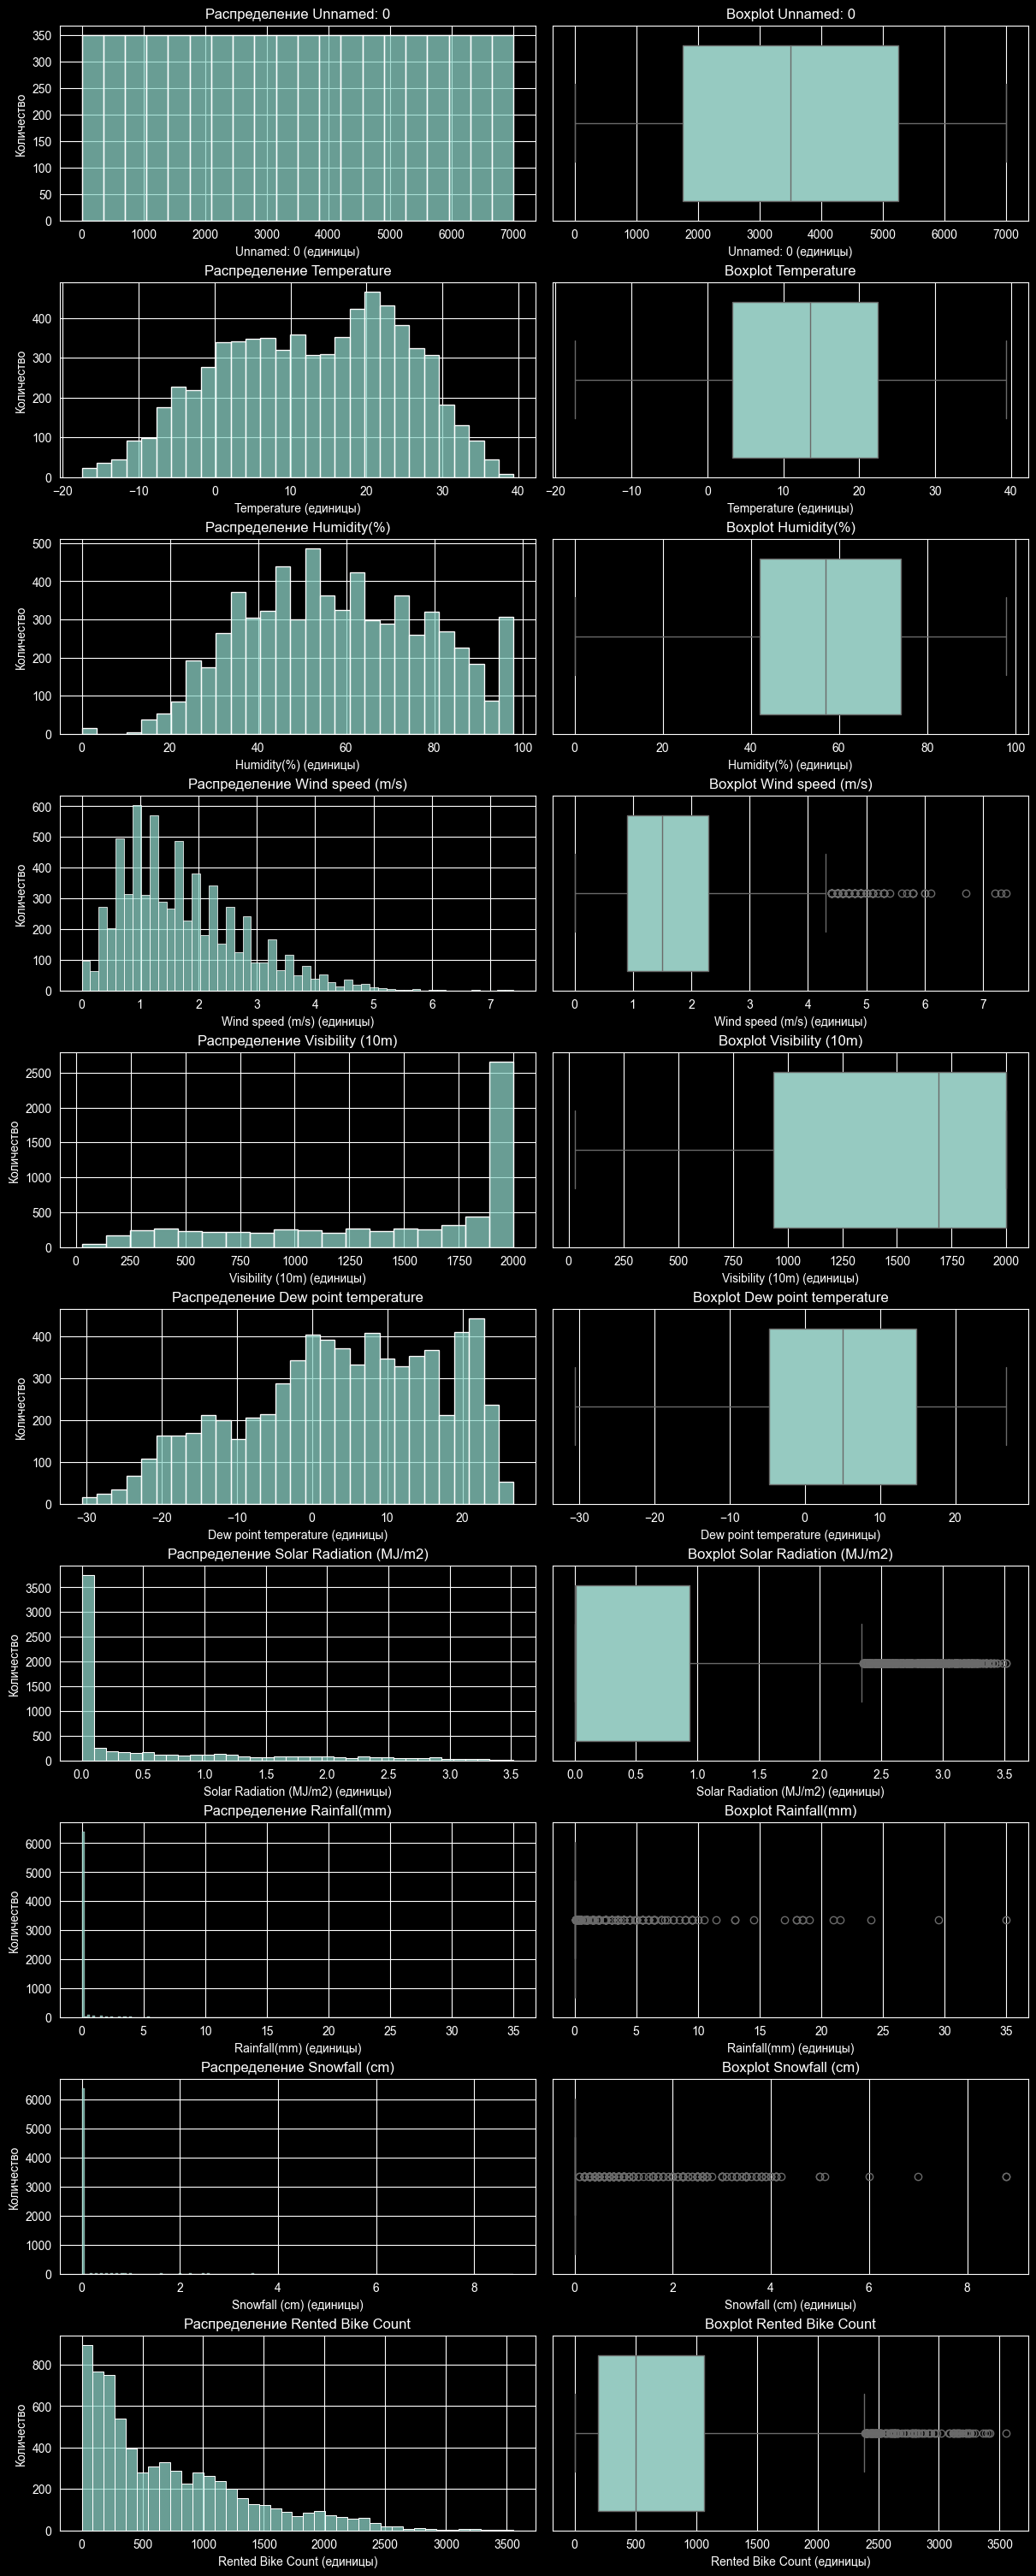

In [33]:
plot_numeric_distributions(df[cols_num])

**Выбросы**
Выбросы заметны у следующих признаков:
- `Wind Speed` - есть случаи порывистого ветра. Это нормально для Сочи, где грозы и шторма нередкость
- `Humidity` - влажность в целом находится в реальных границах от 0 до 98 процентов. Хотя нулевой показатель влажности для приморского города является аномалией и скорее всего 0 - это пропуск или ошибка в замерах и стоит уточнить этот момент у поставщика данных. В рамках этого проекта будем считать нулевую влажность за допустимое значение
- `Solar radiation` - большое количество выбрсоов сосредоточено в диапазоне от ~2.3 до ~3.7. Но эти показатели нормальны для Сочи, где суточная норма солнечной радиации может достигать 25-30 МДж/м² и более. Выбросы на графике получились в следствии большого количества нулевых и околонулевых значений. Они скорее всего вызваны утренними и вечерними замерами, а также замерами в пасмурное время, когда солнечная радиация почти отсутствует
- `Snowfall` - снег в Сочи редкость, поэтому все ненулевые значения на графике считаются за выброс. Но это нормально для Сочи
-  `Rainfall` - дожди в Сочи происходят гораздо чаще чем снегопад, но они кратковременные и с небольшим объемом осадков. Поэтому редкие и сильные дожди считаются на графике за выброс. Но для Сочи это реалистичный график
- `Rented Bike Count` (Таргет) - есть заметные выбросы в районе примерно 2500-3500. Это нормально для дней с высоким спросом

**Распределения**
Несмотря на различия в распределениях признаков, дополнительное приведение их к нормальному распределению не является обязательным. Для алгоритма KNN влияние различий в масштабе устраняется посредством стандартизации признаков (StandardScaler), а для дерева решений форма распределения признаков не оказывает существенного влияния на процесс обучения модели.



### 3.4 Анализ категориальных признаков

Посмотрим на категориальные переменные

Boolean переменные представляют собой закодированный признак `Time Period`. Восстановим его изначальный вид для удобства анализа

In [34]:
# Получение столбцов признака Time Period
cols_bool_ohe = df.select_dtypes('bool').columns.tolist()
cols_bool_ohe

['Time_Period_Evening',
 'Time_Period_Late Evening',
 'Time_Period_Morning',
 'Time_Period_Night']

In [35]:
# Получение маски для недостающего OHE признака
daytime_col_mask = df[cols_bool_ohe].sum(axis=1) == 0
daytime_col_mask[:5]

0    False
1    False
2    False
3    False
4     True
dtype: bool

In [36]:
# Восстановление признака
time_period = pd.DataFrame({'Time period': df[cols_bool_ohe]
    .join(pd.DataFrame({'Time_Period_Daytime': daytime_col_mask}))
    .idxmax(axis=1)
    .str.replace('Time_Period_', '', regex=False)
}, )

Теперь проанализируем категориальные признаки

In [37]:
df_cat = df.select_dtypes(['string']).join(time_period)
df_cat

,Seasons,Holiday,Functioning Day,Time period
0,Autumn,Holiday,Yes,Evening
1,Autumn,No Holiday,Yes,Evening
2,Winter,No Holiday,Yes,Late Evening
3,Winter,No Holiday,Yes,Night
4,Autumn,No Holiday,Yes,Daytime
...,...,...,...,...
7003,Winter,No Holiday,Yes,Evening
7004,Spring,No Holiday,Yes,Night
7005,Autumn,No Holiday,Yes,Morning
7006,Autumn,No Holiday,Yes,Night


In [38]:
# Функция для построения графиков countplot и barplot по данным для категориальных признаков
def plot_categorical_distributions(df, target):
    fig, axes = plt.subplots(
        len(df.columns),
        2,
        figsize=(14, len(df.columns) * 3)
    )

    # если одна колонка
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        data = df.copy()
        data[col] = data[col].fillna('missing')

        # 1. Countplot (частоты)
        sns.countplot(
            data=data,
            x=col,
            ax=axes[i][0]
        )
        axes[i][0].set_title(f'{col} — count')
        axes[i][0].tick_params(axis='x', rotation=30)

        # 2. Barplot (средний target)
        sns.barplot(
            x=df[col],
            y=target,
            errorbar=None,
            ax=axes[i][1]
        )
        axes[i][1].set_title(f'{col} — mean(target)')
        axes[i][1].tick_params(axis='x', rotation=30)

    plt.show()

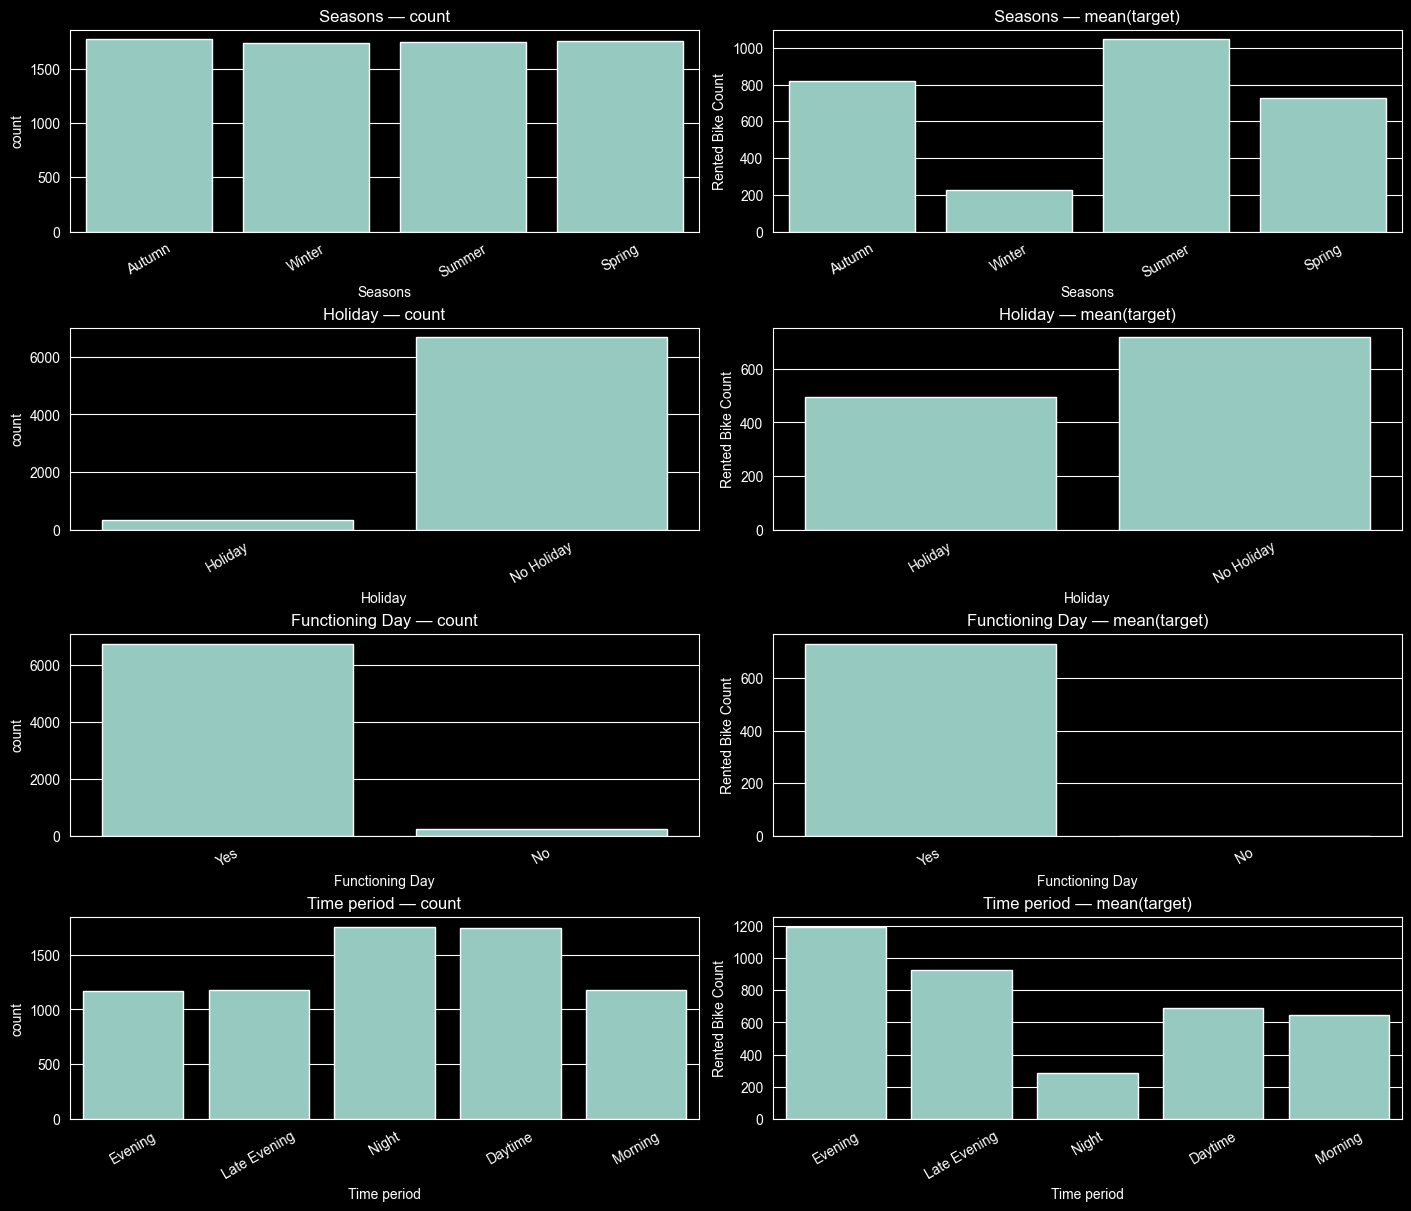

In [39]:
plot_categorical_distributions(df_cat, df[TARGET_COL])

**Распределения**

| Признак             | Распределение по значениям                                  | Среднее значение таргета                                                | Комментарий                                                                                                  |
| ------------------- | ----------------------------------------------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| **Seasons**         | Все категории представлены примерно одинаково               | Наибольшее в Summer, затем Autumn, далее Spring, минимальное в Winter   | Сезонность оказывает существенное влияние на спрос: летом арендуют чаще всего, зимой — заметно реже.         |
| **Holiday**         | Наблюдений с No Holiday значительно больше, чем с Holiday   | В No Holiday среднее выше, чем в Holiday                                | В праздничные дни спрос ниже, однако категория Holiday представлена значительно меньшим числом наблюдений.   |
| **Functioning Day** | Почти все наблюдения относятся к Yes                        | При Yes среднее положительное и высокое, при No практически отсутствует | Нерабочие дни исключают аренду велосипедов; признак выглядит очень информативным.                |
| **Time period**     | Night и Daytime представлены чаще, Morning и Evening — реже | Максимум в Evening, затем Late Evening; минимум в Night                 | Наблюдается выраженная внутрисуточная динамика спроса: пик приходится на вечерние часы, минимум — на ночные. |

**Кодирование**
Предусмотрим кодирование признаков, которое реализуем в пайплайне предобработки данных

- Признак `Time period` корректно закодирован с помощью OHE, оставляем его в изначальном виде
- Признак `Seasons` состоит из 4 уникальных значений, для его кодирования лучше всего подойдет OHE
- Признаки `Holiday` и `Functioning Day` закодируем в виде 0/1 в датасете для дальнейшего применения в моделе

В целом все признаки выглядит перспективно для применения в моделях

### 3.5 Корреляции

Оценим корреляции признаков между собой и целевой переменной с помощью phik и тепловой карты

In [40]:
# Функция для построения тепловой карты
def heatmap(df):
    plt.figure(figsize=(20, 15))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title("Phik Correlation Matrix", fontsize=16)
    plt.show()

# Функция для получения пар признаков со значением их корреляции
def phik_to_pairs(df_phik):
    s = df_phik.stack()
    s = s[s.index.get_level_values(0) != s.index.get_level_values(1)]
    s = s[s.index.get_level_values(0) < s.index.get_level_values(1)]
    s = s.sort_values(ascending=False)
    return s

Для корректного построения phik матрицы требуется определить interval_cols, передав в нее непрерывные числовые признаки. Будем считать таким признаками те, у которых 20 и более уникальных значений

In [41]:
# Вычисление признаков с непрерывными числовыми значениями
DISCRETE_THRESHOLD = 20

continuous_cols = df.columns[df.nunique() > DISCRETE_THRESHOLD].tolist()

continuous_cols

['Unnamed: 0',
 'Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Rented Bike Count']

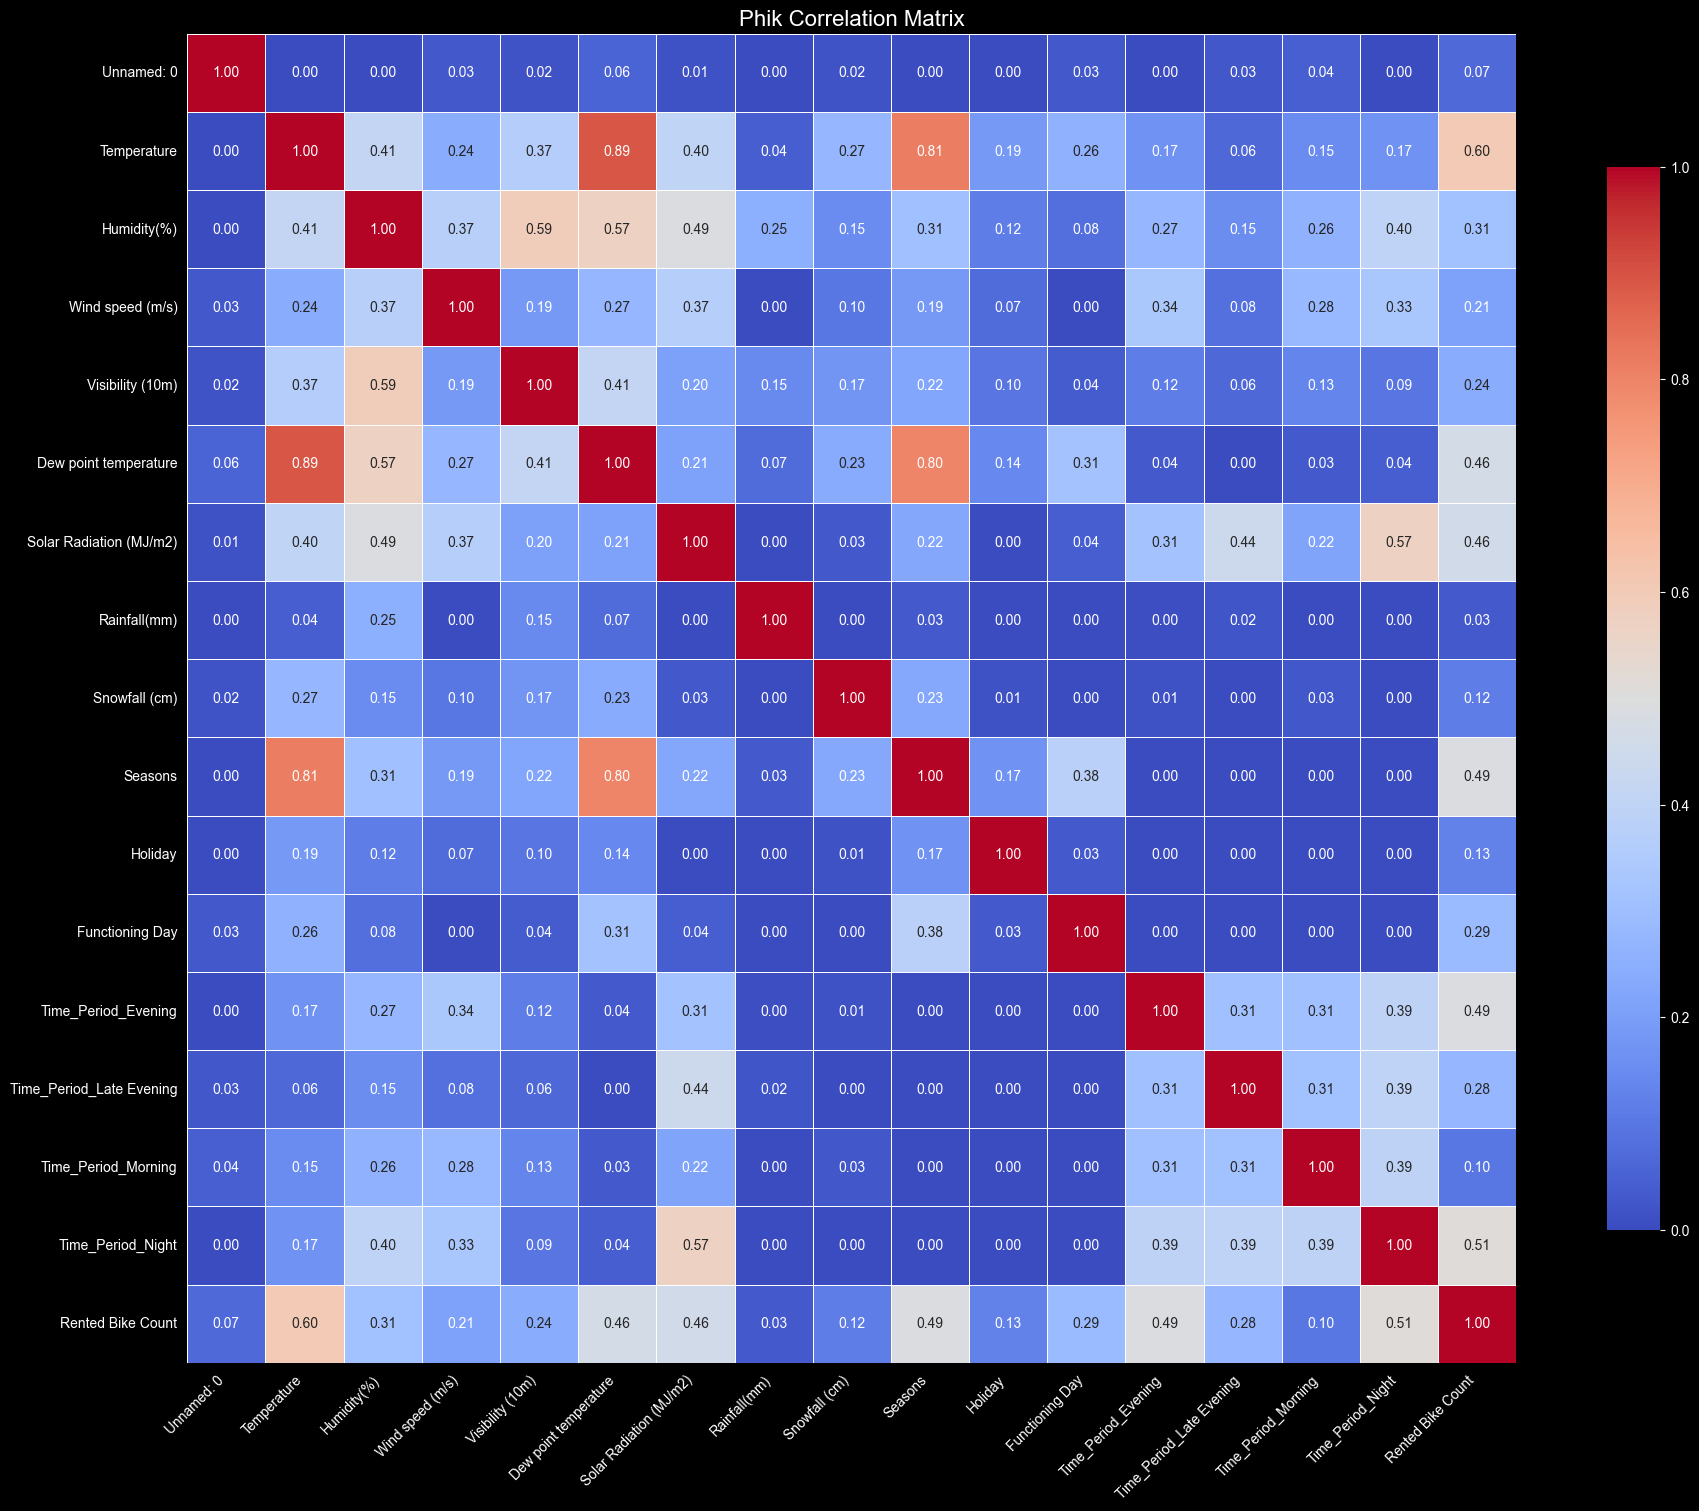

In [42]:
# Построение тепловой карты
df_phik = df.phik_matrix(interval_cols=continuous_cols)
heatmap(df_phik)

Уже хорошо заметны корреляции как признаков между собой, так и с таргетом. Это ожидаемо, так как многие погодные признаки связаны между собой

Посмотрим на корреляцию признаков между собой подробнее

In [43]:
# Топ сильно коррелирующих между собой признаков
phik_to_pairs(df_phik.drop(index=TARGET_COL, columns=TARGET_COL))[:12]

Dew point temperature    Temperature                 0.892561
Seasons                  Temperature                 0.814083
Dew point temperature    Seasons                     0.800099
Humidity(%)              Visibility (10m)            0.587097
Dew point temperature    Humidity(%)                 0.570817
Solar Radiation (MJ/m2)  Time_Period_Night           0.566452
Humidity(%)              Solar Radiation (MJ/m2)     0.490686
Solar Radiation (MJ/m2)  Time_Period_Late Evening    0.440679
Humidity(%)              Temperature                 0.413596
Dew point temperature    Visibility (10m)            0.410392
Solar Radiation (MJ/m2)  Temperature                 0.401338
Humidity(%)              Time_Period_Night           0.397880
dtype: float64

Анализ корреляций показал, что погодные признаки в значительной степени связаны между собой. Особенно сильная корреляция наблюдается между температурой, точкой росы и сезоном (коэффициенты выше 0.8). Это указывает на наличие мультиколлинеарности между частью метеорологических переменных

Для используемых моделей данная особенность имеет различное значение. Для Decision Tree влияние мультиколлинеарности обычно невелико, поскольку дерево самостоятельно выбирает наиболее информативные признаки при разбиениях. Для KNN наличие сильно коррелирующих признаков может быть более заметным, так как расстояния между объектами рассчитываются с учётом всех признаков. В связи с этим удаление части избыточных переменных потенциально может улучшить качество модели за счёт снижения влияния дублирующей информации.

Кроме того, выявленные зависимости открывают возможности для feature engineering. Коррелирующие признаки могут быть объединены в новые, более информативные характеристики, отражающие общие погодные условия. Это позволяет уменьшить избыточность данных, сохранить полезную информацию и в ряде случаев повысить качество и устойчивость моделей.

Выведем отдельно корреляццию с таргетом

In [44]:
# Список признаков в корреляции с таргетом
df_phik.loc[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False).to_frame()

,Rented Bike Count
Temperature,0.603136
Time_Period_Night,0.508885
Seasons,0.491204
Time_Period_Evening,0.489551
Dew point temperature,0.463809
Solar Radiation (MJ/m2),0.456615
Humidity(%),0.308656
Functioning Day,0.288384
Time_Period_Late Evening,0.275677
Visibility (10m),0.241367


**Кореляция с таргетом**
Наибольшую связь с количеством арендованных велосипедов демонстрируют температура (0.60), ночное время суток (0.51), сезон (0.49), вечернее время (0.49), точка росы (0.46) и солнечная радиация (0.46). Это подтверждает, что спрос на велосипеды в первую очередь зависит от погодных условий и временных характеристик. При этом ни один признак не обладает очень высокой корреляцией с целевой переменной, что указывает на влияние совокупности факторов, а не одного доминирующего признака.

## 3.5 Вывод

По итогам EDA можно сделать вывод, что датасет в целом хорошо подготовлен для моделирования спроса на велосипеды. Доля пропусков невелика и может быть обработана в пайплайне без существенной потери информации, явные и неявные дубликаты отсутствуют, а обнаруженные выбросы в погодных показателях и целевой переменной в основном объясняются реальными особенностями наблюдений, а не ошибками данных.

Анализ распределений показал, что спрос на аренду велосипедов заметно зависит от сезона, времени суток, погодных условий и факта работы сервиса. Наиболее высокий спрос наблюдается летом и в вечерние часы, а наиболее низкий - зимой и ночью. Корреляционный анализ дополнительно подтвердил значимость температурных и временных признаков, а также показал наличие связи между рядом погодных переменных, что важно учитывать при построении моделей.

На следующих этапах имеет смысл сосредоточиться на аккуратной обработке пропусков, кодировании категориальных переменных и создании дополнительных признаков, которые помогут лучше отразить погодные и временные закономерности спроса.

## 4. Построение пайплайна предобработки

Создадим пайплайн предобработки признаков, чтобы в дальнейшем применять его перед применением модели. В пайплайн должно войти:
- заполнение пропуском
- нормализация числовых признаков
- корректное кодирование булевых и категориальных признаков


In [45]:
# Создание препроцессора

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer

# Функция вынесена в отдельный файл, так как ее понадобится экспортировать
# вместе с моделью в конце разработки
from features import bool_to_int

def get_preprocessor():

    # OHE подходит и для кодирования категориальных признаков с 2 значениями
    # Благодаря параметру drop одна из двух полученных колонок будет отброшена и 
    # Признак станет булевым, закодированным с помощью 0/1
    ohe_cols = [
        'Seasons', 
        'Holiday', 
        'Functioning Day'
    ]
    # Для числовых колонок применим заполнение пропусков медианой
    # и нормализацию
    num_cols = [
        'Temperature',
        'Humidity(%)',
        'Wind speed (m/s)',
        'Visibility (10m)',
        'Dew point temperature',
        'Solar Radiation (MJ/m2)',
        'Rainfall(mm)',
        'Snowfall (cm)'
    ]
    # Эти признаки закодированы с помощью OHE и boolean переменной, но
    # модели в данном проекте могут работать только с числами,
    # поэтому нужно перевести boolean в числа 0/1
    bool_cols = [
        'Time_Period_Evening',
        'Time_Period_Late Evening',
        'Time_Period_Morning',
        'Time_Period_Night'
    ]

    return ColumnTransformer([
            (
                'ohe',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
                    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
                ]),
                ohe_cols
            ),
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]),
                num_cols
            ),
            (
                'bool',
                Pipeline([
                    # Заполнение пропусков встроено в функцию bool_to_int
                    ('to_int', FunctionTransformer(bool_to_int, feature_names_out='one-to-one'))
                ]),
                bool_cols
            )
        ], 
        remainder='drop'
    )

Проверим работу препроцессора

In [46]:
# Проверка работы препроцессора
preprocessor = get_preprocessor()

pd.DataFrame(
    preprocessor.fit_transform(df),
    columns=preprocessor.get_feature_names_out()
)[:5]

,ohe__Seasons_Spring,ohe__Seasons_Summer,ohe__Seasons_Winter,ohe__Holiday_No Holiday,ohe__Functioning Day_Yes,num__Temperature,num__Humidity(%),num__Wind speed (m/s),num__Visibility (10m),num__Dew point temperature,num__Solar Radiation (MJ/m2),num__Rainfall(mm),num__Snowfall (cm),bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
0,0.0,0.0,0.0,0.0,1.0,0.627909,-1.159392,0.663053,0.928943,0.021371,-0.108476,-0.123783,-0.167282,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,1.0,1.055624,-0.158090,1.441375,0.928943,0.888437,-0.469643,-0.123783,-0.167282,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,1.0,1.0,-1.653236,-0.959132,-0.115268,0.928943,-1.728109,-0.644402,-0.123783,-0.167282,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,1.0,1.0,-1.510664,-1.059262,0.468473,0.928943,-1.659051,-0.644402,-0.123783,-0.167282,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,1.0,0.887893,-1.209457,0.371183,0.928943,0.197853,2.664358,-0.123783,-0.167282,0.0,0.0,0.0,0.0


Препроцессор для подготовки данных готов. Его можно применять далее в составе пайплайна модели

## 5. Обучение базовых нелинейных моделей


## 6. Подбор гиперпараметров с Optuna


### 6.1. Оптимизация kNN Regressor


### 6.2. Оптимизация Decision Tree Regressor


## 7. Feature Engineering

Попробуем создать несколько признаков на основе имеющихся данных. Новые признаки должны лучше улавливать комбинацию текущих


## 8. Сравнение лучших моделей


## 9. Финальная проверка лучшей модели на тестовой выборке


## 10. Интерпретация результатов и важность признаков


## 11. Подготовка финального пайплайна и артефактов модели


## 12. Итоговые выводы и рекомендации для BikeSouth
